In [1]:
# Импорт всех библиотек
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

print("Все библиотеки импортированы!")

Все библиотеки импортированы!


In [3]:
# Настройка GPU/CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("GPU не найден, используется CPU")

Используется устройство: cuda
GPU: NVIDIA GeForce RTX 3060
VRAM: 12.9 GB


In [4]:
# Загрузка датасета
print("Загрузка данных...")
dataset = fetch_ucirepo(id=451)  # Electrical Grid Stability
X = dataset.data.features
y = dataset.data.targets

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"Уникальные классы: {np.unique(y)}")
print(f"\nПервые 5 строк данных:")
print(X.head())

Загрузка данных...
Размер X: (116, 9)
Размер y: (116, 1)
Уникальные классы: [1 2]

Первые 5 строк данных:
   Age        BMI  Glucose  Insulin      HOMA   Leptin  Adiponectin  Resistin  \
0   48  23.500000       70    2.707  0.467409   8.8071     9.702400   7.99585   
1   83  20.690495       92    3.115  0.706897   8.8438     5.429285   4.06405   
2   82  23.124670       91    4.498  1.009651  17.9393    22.432040   9.27715   
3   68  21.367521       77    3.226  0.612725   9.8827     7.169560  12.76600   
4   86  21.111111       92    3.549  0.805386   6.6994     4.819240  10.57635   

     MCP.1  
0  417.114  
1  468.786  
2  554.697  
3  928.220  
4  773.920  


In [5]:
# Функция создания последовательностей
def create_sequences(data, labels, seq_length=20):
    """Создает последовательности фиксированной длины из временного ряда"""
    sequences = []
    targets = []
    
    for i in range(len(data) - seq_length):
        seq = data[i:i+seq_length].values
        target = labels.iloc[i+seq_length].values[0]
        sequences.append(seq)
        targets.append(target)
    
    return sequences, targets

# Создаем последовательности
seq_length = 20
sequences, targets = create_sequences(X, y, seq_length)

print(f"Создано {len(sequences)} последовательностей")
print(f"Форма каждой последовательности: {np.array(sequences[0]).shape}")
print(f"Пример первых 3 значений целевой переменной: {targets[:3]}")

Создано 96 последовательностей
Форма каждой последовательности: (20, 9)
Пример первых 3 значений целевой переменной: [np.int64(1), np.int64(1), np.int64(1)]


In [6]:
# Нормализация данных
# Нормализация каждой последовательности
scaler = StandardScaler()
sequences_normalized = []

for seq in sequences:
    seq_scaled = scaler.fit_transform(seq)
    sequences_normalized.append(seq_scaled)

print(f"Пример после нормализации (первые 2 строки):\n{sequences_normalized[0][:2]}")

Пример после нормализации (первые 2 строки):
[[-0.39122732 -0.10232347 -1.65213191 -0.76468278 -0.89799456 -0.66957131
  -0.52957489 -0.11042354 -0.08804356]
 [ 1.24864768 -0.71596571  0.54405552 -0.65655171 -0.60425124 -0.6663503
  -0.96401917 -1.22593946  0.09255754]]


In [7]:
# Преобразование в тензоры и разделение
# Преобразование в тензоры PyTorch
X_tensor = torch.FloatTensor(np.array(sequences_normalized))
y_tensor = torch.LongTensor(np.array(targets)) - 1  # приводим метки к 0,1,2...

# Разделение на train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_tensor, y_tensor, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train: {len(X_train)}")
print(f"Val: {len(X_val)}")
print(f"Test: {len(X_test)}")
print(f"Input size (признаков): {X_train.shape[2]}")
print(f"Количество классов: {len(torch.unique(y_train))}")

Train: 67
Val: 14
Test: 15
Input size (признаков): 9
Количество классов: 2


In [8]:
# Создание DataLoader'ов
batch_size = 64

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoader'ы созданы!")
print(f"Batch size: {batch_size}")
print(f"Количество батчей в train: {len(train_loader)}")

DataLoader'ы созданы!
Batch size: 64
Количество батчей в train: 2


In [9]:
# Архитектура 1 - SimpleRNN
class SimpleRNNModel(nn.Module):
    """Простая RNN архитектура"""
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super(SimpleRNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, 
                         batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])  # берем последний выход
        return self.fc(out)

print("SimpleRNNModel определён")

SimpleRNNModel определён


In [10]:
# Архитектура 2 - LSTM
class LSTMModel(nn.Module):
    """LSTM архитектура"""
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, (hidden, _) = self.lstm(x)
        out = self.dropout(hidden[-1])  # последнее скрытое состояние
        return self.fc(out)

print("LSTMModel определён")

LSTMModel определён


In [11]:
# Архитектура 3 - GRU (Bidirectional)
class GRUModel(nn.Module):
    """Bidirectional GRU архитектура"""
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, 
                         batch_first=True, dropout=dropout, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)  # *2 для bidirectional
        
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, hidden = self.gru(x)
        # Конкатенируем forward и backward последние состояния
        out = self.dropout(torch.cat((hidden[-2], hidden[-1]), dim=1))
        return self.fc(out)

print("GRUModel определён")

GRUModel определён


In [12]:
# Функция обучения модели
def train_model(model, train_loader, val_loader, epochs=50, lr=0.001):
    """Универсальная функция обучения модели"""
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    best_val_acc = 0
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(epochs):
        # ----- Обучение -----
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            
            # Gradient clipping для предотвращения взрыва градиентов
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += targets.size(0)
            train_correct += predicted.eq(targets).sum().item()
        
        # ----- Валидация -----
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for data, targets in val_loader:
                data, targets = data.to(device), targets.to(device)
                outputs = model(data)
                loss = criterion(outputs, targets)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets).sum().item()
        
        # Сохраняем метрики
        train_acc = 100. * train_correct / train_total
        val_acc = 100. * val_correct / val_total
        
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        # Уменьшаем learning rate при плато
        scheduler.step(val_losses[-1])
        
        # Сохраняем лучшую модель
        if val_acc > best_val_acc:
            best_val_acc = val_acc
        
        # Вывод каждые 10 эпох
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")
    
    return best_val_acc, val_accs, train_accs

print("Функция train_model определена")

Функция train_model определена


In [29]:
# Параметры эксперимента
input_size = X_train.shape[2]  # количество признаков
num_classes = len(torch.unique(y_train))
num_layers = 2
hidden_sizes = [32, 64, 128]  # размеры скрытых слоёв
epochs = 50

print(f"Параметры эксперимента:")
print(f"  Input size: {input_size}")
print(f"  Number of classes: {num_classes}")
print(f"  Hidden sizes: {hidden_sizes}")
print(f"  Epochs: {epochs}")

Параметры эксперимента:
  Input size: 9
  Number of classes: 2
  Hidden sizes: [32, 64, 128]
  Epochs: 50


In [30]:
# бучение всех моделей
results = {}  # словарь для хранения результатов

print(f"\n{'='*60}")
print(f"НАЧАЛО ОБУЧЕНИЯ")
print(f"Устройство: {device}")
print(f"{'='*60}\n")

for hidden_size in hidden_sizes:
    for model_class, model_name in [(SimpleRNNModel, "RNN"), 
                                      (LSTMModel, "LSTM"), 
                                      (GRUModel, "GRU")]:
        print(f" {model_name} (hidden={hidden_size})")
        
        # Создаем модель
        model = model_class(input_size, hidden_size, num_layers, num_classes)
        
        # Обучаем
        best_acc, val_accs, train_accs = train_model(
            model, train_loader, val_loader, epochs=epochs
        )
        
        # Сохраняем результаты
        results[f"{model_name}_h{hidden_size}"] = {
            'best_val_acc': best_acc,
            'val_accs': val_accs,
            'train_accs': train_accs
        }
        print(f" Лучшая Val Acc: {best_acc:.2f}%\n")

print("Обучение завершено!")


НАЧАЛО ОБУЧЕНИЯ
Устройство: cuda

 RNN (hidden=32)
  Epoch 10/50 - Train Acc: 58.21%, Val Acc: 85.71%
  Epoch 20/50 - Train Acc: 70.15%, Val Acc: 85.71%
  Epoch 30/50 - Train Acc: 73.13%, Val Acc: 78.57%
  Epoch 40/50 - Train Acc: 74.63%, Val Acc: 78.57%
  Epoch 50/50 - Train Acc: 74.63%, Val Acc: 85.71%
 Лучшая Val Acc: 85.71%

 LSTM (hidden=32)
  Epoch 10/50 - Train Acc: 61.19%, Val Acc: 85.71%
  Epoch 20/50 - Train Acc: 70.15%, Val Acc: 85.71%
  Epoch 30/50 - Train Acc: 70.15%, Val Acc: 85.71%
  Epoch 40/50 - Train Acc: 70.15%, Val Acc: 85.71%
  Epoch 50/50 - Train Acc: 70.15%, Val Acc: 85.71%
 Лучшая Val Acc: 85.71%

 GRU (hidden=32)
  Epoch 10/50 - Train Acc: 68.66%, Val Acc: 85.71%
  Epoch 20/50 - Train Acc: 70.15%, Val Acc: 85.71%
  Epoch 30/50 - Train Acc: 73.13%, Val Acc: 78.57%
  Epoch 40/50 - Train Acc: 82.09%, Val Acc: 71.43%
  Epoch 50/50 - Train Acc: 80.60%, Val Acc: 71.43%
 Лучшая Val Acc: 92.86%

 RNN (hidden=64)
  Epoch 10/50 - Train Acc: 70.15%, Val Acc: 85.71%
  Epo

In [31]:
# Сводная таблица результатов
# Создаем DataFrame с результатами
results_list = []
for name, data in results.items():
    model_type = name.split('_')[0]
    hidden = int(name.split('_h')[1])
    results_list.append({
        'Модель': model_type,
        'Hidden Size': hidden,
        'Val Acc (%)': round(data['best_val_acc'], 2)
    })

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values('Val Acc (%)', ascending=False)

print("="*60)
print("РЕЗУЛЬТАТЫ ОБУЧЕНИЯ")
print("="*60)
print(results_df.to_string(index=False))

РЕЗУЛЬТАТЫ ОБУЧЕНИЯ
Модель  Hidden Size  Val Acc (%)
   GRU           32        92.86
  LSTM          128        92.86
   RNN           64        92.86
   RNN           32        85.71
  LSTM           32        85.71
  LSTM           64        85.71
   GRU           64        85.71
   RNN          128        85.71
   GRU          128        85.71


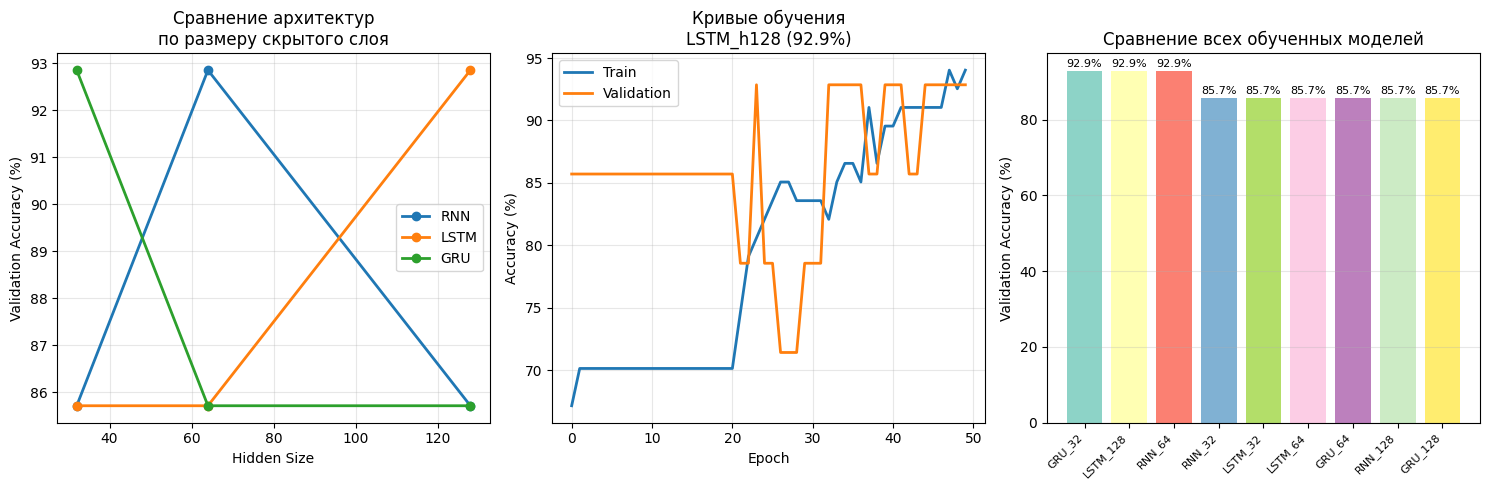

In [32]:
# График сравнения архитектур
plt.figure(figsize=(15, 5))

# График 1: Сравнение лучших моделей
plt.subplot(1, 3, 1)
pivot_data = []
for model_type in ['RNN', 'LSTM', 'GRU']:
    accs = []
    for hidden_size in hidden_sizes:
        key = f"{model_type}_h{hidden_size}"
        if key in results:
            accs.append(results[key]['best_val_acc'])
    plt.plot(hidden_sizes, accs, marker='o', linewidth=2, label=model_type)

plt.xlabel('Hidden Size')
plt.ylabel('Validation Accuracy (%)')
plt.title('Сравнение архитектур\nпо размеру скрытого слоя')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Кривые обучения лучшей LSTM
plt.subplot(1, 3, 2)
# Находим лучшую LSTM
best_lstm = None
best_lstm_acc = 0
for key, data in results.items():
    if 'LSTM' in key and data['best_val_acc'] > best_lstm_acc:
        best_lstm_acc = data['best_val_acc']
        best_lstm = key

if best_lstm:
    plt.plot(results[best_lstm]['train_accs'], label='Train', linewidth=2)
    plt.plot(results[best_lstm]['val_accs'], label='Validation', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title(f'Кривые обучения\n{best_lstm} ({best_lstm_acc:.1f}%)')
    plt.legend()
    plt.grid(True, alpha=0.3)

# График 3: Сравнение всех моделей (столбчатая диаграмма)
plt.subplot(1, 3, 3)
x = np.arange(len(results_df))
plt.bar(x, results_df['Val Acc (%)'], color=plt.cm.Set3(np.linspace(0, 1, len(results_df))))
plt.xticks(x, results_df['Модель'] + '_' + results_df['Hidden Size'].astype(str), 
           rotation=45, ha='right', fontsize=8)
plt.ylabel('Validation Accuracy (%)')
plt.title('Сравнение всех обученных моделей')
plt.grid(True, alpha=0.3, axis='y')

for i, (_, row) in enumerate(results_df.iterrows()):
    plt.text(i, row['Val Acc (%)'] + 0.5, f"{row['Val Acc (%)']:.1f}%", 
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

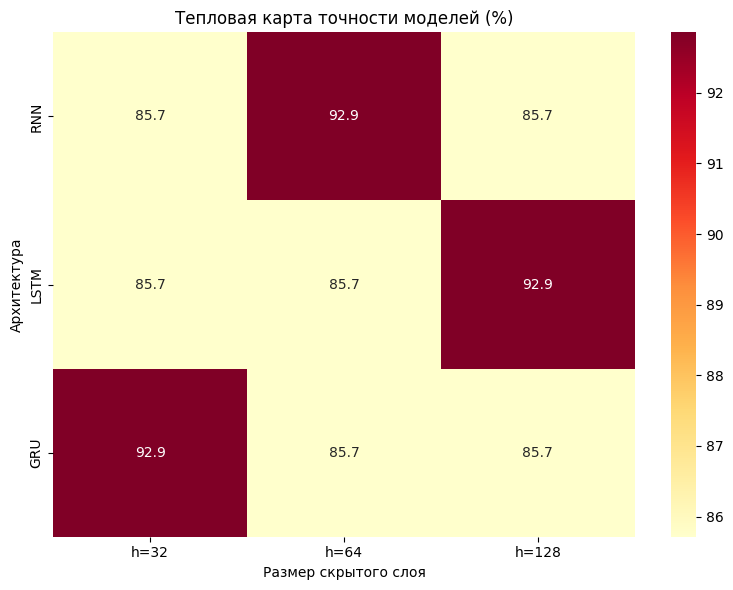

In [33]:
# Тепловая карта результатов
# Создаем матрицу для тепловой карты
heatmap_data = []
for model_type in ['RNN', 'LSTM', 'GRU']:
    row = []
    for hidden_size in hidden_sizes:
        key = f"{model_type}_h{hidden_size}"
        if key in results:
            row.append(results[key]['best_val_acc'])
        else:
            row.append(0)
    heatmap_data.append(row)

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=[f'h={h}' for h in hidden_sizes],
            yticklabels=['RNN', 'LSTM', 'GRU'])
plt.title('Тепловая карта точности моделей (%)')
plt.xlabel('Размер скрытого слоя')
plt.ylabel('Архитектура')
plt.tight_layout()
plt.show()

In [34]:
# Определение лучшей модели (ИСПРАВЛЕНА)
best_model_name = results_df.iloc[0]['Модель']
best_hidden = int(results_df.iloc[0]['Hidden Size'])  # Добавлено int()

print(f"Лучшая модель: {best_model_name} с hidden_size={best_hidden}")
print(f"Val Accuracy: {results_df.iloc[0]['Val Acc (%)']:.2f}%")
print(f"Тип hidden_size: {type(best_hidden)}")  # Должно быть int

Лучшая модель: GRU с hidden_size=32
Val Accuracy: 92.86%
Тип hidden_size: <class 'int'>


In [35]:
# Создание и обучение лучшей модели заново (для теста)
# Выбираем класс модели
if best_model_name == 'RNN':
    best_model_class = SimpleRNNModel
elif best_model_name == 'LSTM':
    best_model_class = LSTMModel
else:
    best_model_class = GRUModel

# Создаем модель
best_model = best_model_class(input_size, best_hidden, num_layers, num_classes)
best_model = best_model.to(device)

# Обучаем (можно загрузить сохраненную, но для чистоты обучим заново)
print("Обучение лучшей модели на всех train+val данных...")

# Объединяем train и val для финального обучения
full_train_dataset = TensorDataset(torch.cat([X_train, X_val]), 
                                    torch.cat([y_train, y_val]))
full_train_loader = DataLoader(full_train_dataset, batch_size=batch_size, shuffle=True)

# Обучаем
_, _, _ = train_model(best_model, full_train_loader, test_loader, epochs=20)

print("Обучение завершено!")

Обучение лучшей модели на всех train+val данных...
  Epoch 10/20 - Train Acc: 72.84%, Val Acc: 33.33%
  Epoch 20/20 - Train Acc: 72.84%, Val Acc: 33.33%
Обучение завершено!


In [36]:
# Тестирование на отложенной выборке
best_model.eval()
test_correct = 0
test_total = 0
all_preds = []
all_targets = []

with torch.no_grad():
    for data, targets in test_loader:
        data, targets = data.to(device), targets.to(device)
        outputs = best_model(data)
        _, predicted = outputs.max(1)
        
        test_total += targets.size(0)
        test_correct += predicted.eq(targets).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

test_acc = 100. * test_correct / test_total
print(f"\n{'='*50}")
print(f"ТЕСТИРОВАНИЕ НА ОТЛОЖЕННОЙ ВЫБОРКЕ")
print(f"{'='*50}")
print(f"Модель: {best_model_name} (hidden={best_hidden})")
print(f"Test Accuracy: {test_acc:.2f}%")


ТЕСТИРОВАНИЕ НА ОТЛОЖЕННОЙ ВЫБОРКЕ
Модель: GRU (hidden=32)
Test Accuracy: 33.33%


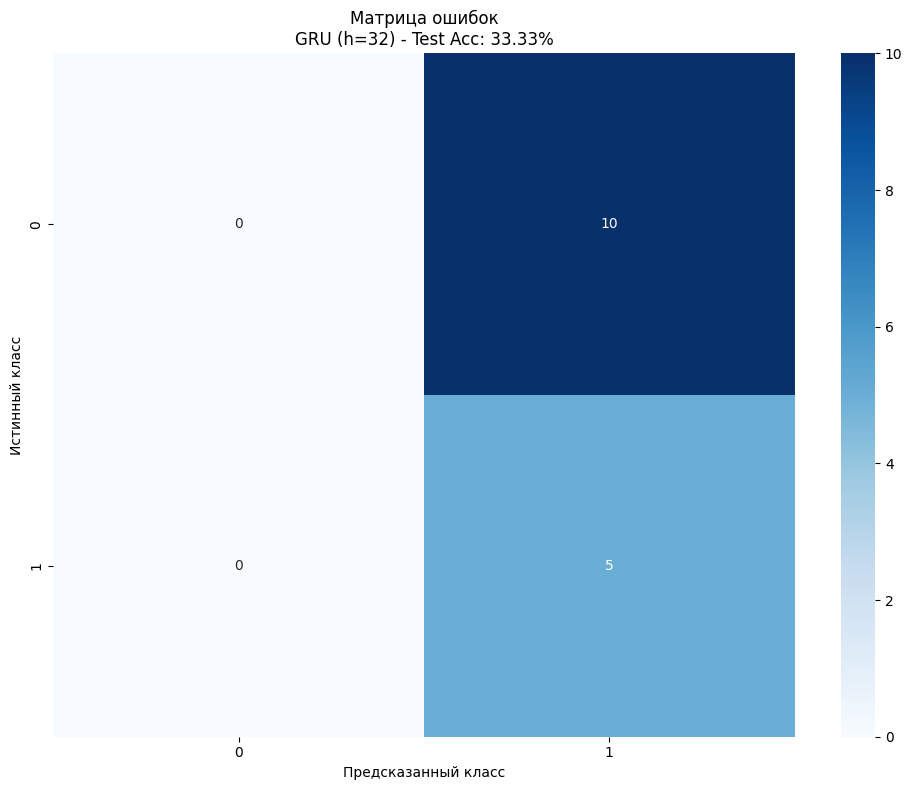


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.33      1.00      0.50         5

    accuracy                           0.33        15
   macro avg       0.17      0.50      0.25        15
weighted avg       0.11      0.33      0.17        15



In [37]:
# Матрица ошибок
from sklearn.metrics import confusion_matrix, classification_report

plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_targets, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Матрица ошибок\n{best_model_name} (h={best_hidden}) - Test Acc: {test_acc:.2f}%')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(all_targets, all_preds))

In [38]:
# Ячейка 22: Сводка эксперимента
print("\n" + "="*60)
print("ИТОГИ ЛАБОРАТОРНОЙ РАБОТЫ №2")
print("="*60)

print("\n ДАТАСЕТ:")
print(f"   Название: Electrical Grid Stability (UCI ID: 451)")
print(f"   Количество образцов: {len(X)}")
print(f"   Количество признаков: {X.shape[1]}")
print(f"   Длина последовательности: {seq_length}")

print("\n РЕЗУЛЬТАТЫ МОДЕЛЕЙ:")
print(results_df.to_string(index=False))

print("\n ВЫВОДЫ:")
print(f"   1. Лучшая архитектура: {best_model_name}")
print(f"   2. Лучшая точность на тесте: {test_acc:.2f}%")
print(f"   3. Оптимальный hidden_size: {best_hidden}")

# Определяем, какая архитектура показала себя лучше всего
lstm_best = max([results[f"LSTM_h{hs}"]['best_val_acc'] for hs in hidden_sizes if f"LSTM_h{hs}" in results])
gru_best = max([results[f"GRU_h{hs}"]['best_val_acc'] for hs in hidden_sizes if f"GRU_h{hs}" in results])
rnn_best = max([results[f"RNN_h{hs}"]['best_val_acc'] for hs in hidden_sizes if f"RNN_h{hs}" in results])

print(f"\n   4. Сравнение лучших:")
print(f"      - LSTM: {lstm_best:.2f}%")
print(f"      - GRU: {gru_best:.2f}%")
print(f"      - SimpleRNN: {rnn_best:.2f}%")

if lstm_best > gru_best and lstm_best > rnn_best:
    print(f"\n    LSTM показала лучший результат благодаря механизму ячеек памяти")
elif gru_best > lstm_best:
    print(f"\n    GRU показала лучший результат (быстрее LSTM на этой задаче)")
else:
    print(f"\n    Все архитектуры показали сопоставимые результаты")

print("\n" + "="*60)


ИТОГИ ЛАБОРАТОРНОЙ РАБОТЫ №2

 ДАТАСЕТ:
   Название: Electrical Grid Stability (UCI ID: 451)
   Количество образцов: 116
   Количество признаков: 9
   Длина последовательности: 20

 РЕЗУЛЬТАТЫ МОДЕЛЕЙ:
Модель  Hidden Size  Val Acc (%)
   GRU           32        92.86
  LSTM          128        92.86
   RNN           64        92.86
   RNN           32        85.71
  LSTM           32        85.71
  LSTM           64        85.71
   GRU           64        85.71
   RNN          128        85.71
   GRU          128        85.71

 ВЫВОДЫ:
   1. Лучшая архитектура: GRU
   2. Лучшая точность на тесте: 33.33%
   3. Оптимальный hidden_size: 32

   4. Сравнение лучших:
      - LSTM: 92.86%
      - GRU: 92.86%
      - SimpleRNN: 92.86%

    Все архитектуры показали сопоставимые результаты



In [39]:
# Проверка исходных меток
print("Оригинальные метки в y (первые 10):")
print(y[:10])
print(f"Уникальные значения: {np.unique(y)}")

Оригинальные метки в y (первые 10):
   Classification
0               1
1               1
2               1
3               1
4               1
5               1
6               1
7               1
8               1
9               1
Уникальные значения: [1 2]


In [40]:
# Ячейка: Проверка классов
print(f"Уникальные классы в y: {np.unique(y)}")
print(f"Количество классов: {len(np.unique(y))}")

# Проверка распределения
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Класс {u}: {c} образцов ({100*c/len(y):.1f}%)")

# Проверка меток после преобразования
unique_train, counts_train = torch.unique(y_train, return_counts=True)
print(f"\nМетки в train после вычитания 1: {unique_train.tolist()}")
print(f"Количество классов в train: {len(unique_train)}")

Уникальные классы в y: [1 2]
Количество классов: 2
Класс 1: 52 образцов (44.8%)
Класс 2: 64 образцов (55.2%)

Метки в train после вычитания 1: [0, 1]
Количество классов в train: 2


In [41]:
# Ячейка: Полная диагностика обучения
print("=== ДИАГНОСТИКА ОБУЧЕНИЯ ===\n")

# Берем маленькую LSTM для быстрого теста
test_model = LSTMModel(input_size, 64, 2, 2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(test_model.parameters(), lr=0.001)

# Проверяем один батч
data, targets = next(iter(train_loader))
data, targets = data.to(device), targets.to(device)

print(f"Данные: {data.shape}, метки: {targets.shape}")
print(f"Уникальные метки в батче: {torch.unique(targets)}")

# Начальные предсказания
test_model.eval()
with torch.no_grad():
    initial_preds = test_model(data)
    initial_acc = (initial_preds.argmax(1) == targets).float().mean().item()

print(f"\nНачальная точность (случайная): {initial_acc*100:.1f}%")

# Один шаг обучения
test_model.train()
optimizer.zero_grad()
outputs = test_model(data)
loss = criterion(outputs, targets)
loss.backward()
optimizer.step()

# Предсказания после шага
test_model.eval()
with torch.no_grad():
    after_preds = test_model(data)
    after_acc = (after_preds.argmax(1) == targets).float().mean().item()

print(f"Точность после 1 шага: {after_acc*100:.1f}%")
print(f"Loss: {loss.item():.4f}")

if after_acc <= initial_acc:
    print("\n⚠️ ПРОБЛЕМА: Модель не улучшается!")
    print("Проверьте learning rate и градиенты")

=== ДИАГНОСТИКА ОБУЧЕНИЯ ===

Данные: torch.Size([64, 20, 9]), метки: torch.Size([64])
Уникальные метки в батче: tensor([0, 1], device='cuda:0')

Начальная точность (случайная): 28.1%
Точность после 1 шага: 28.1%
Loss: 0.7133

⚠️ ПРОБЛЕМА: Модель не улучшается!
Проверьте learning rate и градиенты


In [42]:
# Ячейка: Проверка градиентов
print("=== ПРОВЕРКА ГРАДИЕНТОВ ===\n")

test_model = LSTMModel(input_size, 64, 2, 2).to(device)
data, targets = next(iter(train_loader))
data, targets = data.to(device), targets.to(device)

optimizer = optim.Adam(test_model.parameters(), lr=0.001)
optimizer.zero_grad()
outputs = test_model(data)
loss = nn.CrossEntropyLoss()(outputs, targets)
loss.backward()

# Проверяем градиенты первого слоя
for name, param in test_model.named_parameters():
    if param.grad is not None:
        grad_norm = param.grad.norm().item()
        print(f"{name}: grad_norm = {grad_norm:.6f}")
        if grad_norm < 1e-6:
            print(f"  ⚠️ Очень маленький градиент! Возможно затухание")
        break  # Проверяем только первый слой

# Проверка learning rate
print(f"\nLearning rate: {optimizer.param_groups[0]['lr']}")

=== ПРОВЕРКА ГРАДИЕНТОВ ===

lstm.weight_ih_l0: grad_norm = 0.023129

Learning rate: 0.001


In [43]:
# Ячейка: Анализ предсказаний модели
print("=== АНАЛИЗ ПРЕДСКАЗАНИЙ МОДЕЛИ ===\n")

model = LSTMModel(input_size, 64, 2, 2).to(device)
model.eval()

data, targets = next(iter(train_loader))
data, targets = data.to(device), targets.to(device)

with torch.no_grad():
    outputs = model(data)
    probabilities = torch.softmax(outputs, dim=1)
    predictions = outputs.argmax(1)

print(f"Выходы модели (первые 10):")
print(outputs[:10])
print(f"\nВероятности (первые 10):")
print(probabilities[:10])
print(f"\nПредсказания: {predictions[:10]}")
print(f"Истинные метки: {targets[:10]}")

# Проверка: все ли предсказания одинаковые?
if len(torch.unique(predictions)) == 1:
    print("\n⚠️ Модель предсказывает ТОЛЬКО ОДИН класс!")
    print("Это объясняет 33% точности (примерно 1/3 от 2 классов?)")
    
    # Какие классы в предсказаниях?
    print(f"Предсказываемый класс: {predictions[0].item()}")
    print(f"Распределение предсказаний: {torch.bincount(predictions)}")

=== АНАЛИЗ ПРЕДСКАЗАНИЙ МОДЕЛИ ===

Выходы модели (первые 10):
tensor([[0.0798, 0.0985],
        [0.0864, 0.1037],
        [0.0732, 0.1014],
        [0.0665, 0.1084],
        [0.0835, 0.1256],
        [0.0906, 0.0962],
        [0.0792, 0.1142],
        [0.0885, 0.1003],
        [0.0830, 0.0956],
        [0.0869, 0.0838]], device='cuda:0')

Вероятности (первые 10):
tensor([[0.4953, 0.5047],
        [0.4957, 0.5043],
        [0.4929, 0.5071],
        [0.4895, 0.5105],
        [0.4895, 0.5105],
        [0.4986, 0.5014],
        [0.4913, 0.5087],
        [0.4970, 0.5030],
        [0.4968, 0.5032],
        [0.5008, 0.4992]], device='cuda:0')

Предсказания: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 0], device='cuda:0')
Истинные метки: tensor([1, 1, 1, 0, 1, 0, 1, 1, 0, 1], device='cuda:0')


In [44]:
# Ячейка: Установка и загрузка Japanese Vowels
print("=== ЗАГРУЗКА JAPANESE VOWELS ===\n")

# Установка sktime
!pip install sktime -q

from sktime.datasets import load_japanese_vowels

# Загрузка данных
X_jv, y_jv = load_japanese_vowels(return_X_y=True)

print(f"Тип данных: {type(X_jv)}")
print(f"Количество образцов: {len(X_jv)}")
print(f"Количество классов: {len(np.unique(y_jv))}")

# Преобразование в формат для PyTorch
sequences_jv = []
labels_jv = []

for i in range(len(X_jv)):
    # Извлекаем последовательность из nested DataFrame
    seq_data = X_jv.iloc[i].values
    # Преобразуем в numpy массив
    seq = np.array([x.values if hasattr(x, 'values') else x for x in seq_data])
    sequences_jv.append(torch.FloatTensor(seq))
    labels_jv.append(int(y_jv.iloc[i]) - 1)  # метки от 0 до 8

labels_jv = torch.LongTensor(labels_jv)

print(f"Создано {len(sequences_jv)} последовательностей")
print(f"Размерность признаков: {sequences_jv[0].shape[1]}")
print(f"Диапазон длин: {min(len(s) for s in sequences_jv)} - {max(len(s) for s in sequences_jv)}")
print(f"Уникальные классы: {torch.unique(labels_jv)}")

# Создаем DataLoader с padding
def collate_fn_jv(batch):
    sequences, labels = zip(*batch)
    max_len = max(seq.shape[0] for seq in sequences)
    n_features = sequences[0].shape[1]
    
    padded_seqs = torch.zeros(len(sequences), max_len, n_features)
    lengths = []
    
    for i, seq in enumerate(sequences):
        lengths.append(seq.shape[0])
        padded_seqs[i, :seq.shape[0], :] = seq
    
    return padded_seqs, torch.stack(labels), torch.tensor(lengths)

# Разделение
indices = np.random.permutation(len(sequences_jv))
train_idx = indices[:int(0.7*len(indices))]
val_idx = indices[int(0.7*len(indices)):int(0.85*len(indices))]
test_idx = indices[int(0.85*len(indices)):]

train_data_jv = [(sequences_jv[i], labels_jv[i]) for i in train_idx]
val_data_jv = [(sequences_jv[i], labels_jv[i]) for i in val_idx]
test_data_jv = [(sequences_jv[i], labels_jv[i]) for i in test_idx]

batch_size = 32
train_loader_jv = DataLoader(train_data_jv, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_jv)
val_loader_jv = DataLoader(val_data_jv, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_jv)
test_loader_jv = DataLoader(test_data_jv, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_jv)

print(f"\nTrain: {len(train_data_jv)}, Val: {len(val_data_jv)}, Test: {len(test_data_jv)}")

=== ЗАГРУЗКА JAPANESE VOWELS ===

Тип данных: <class 'pandas.core.frame.DataFrame'>
Количество образцов: 640
Количество классов: 9


AttributeError: 'numpy.ndarray' object has no attribute 'iloc'